In [1]:
import numpy as np
import pandas as pd
import math

import jax
import jax.numpy as jnp

import seaborn as sns
import matplotlib.pyplot as plt


import optax
from tqdm import tqdm

In [2]:
data = pd.read_csv("temperature.csv")
data.Year = pd.to_datetime(data.Year)
data.head()

,Year,Anomaly
0,1850-01-01,-0.36
1,1850-02-01,-0.12
2,1850-03-01,-0.23
3,1850-04-01,-0.19
4,1850-05-01,-0.19


<Axes: xlabel='Year', ylabel='Anomaly'>

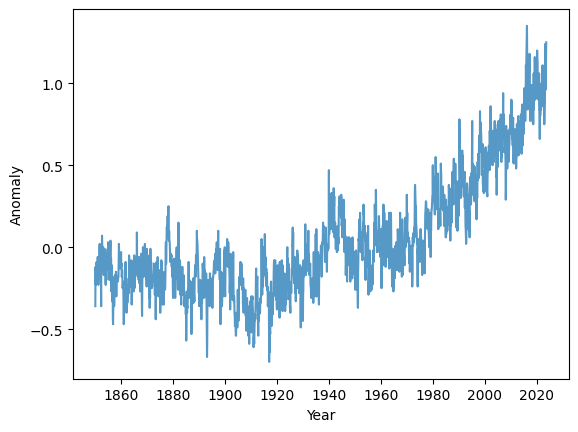

In [3]:
sns.lineplot(data, x='Year', y='Anomaly', alpha=0.75)

In [4]:
Xoriginal = data.Anomaly.to_numpy()


# Minmax normalize
m,M = Xoriginal.min(), Xoriginal.max()
X = (Xoriginal - m)/(M-m)

seqlen = 12
Xtrain = [X[i:i+seqlen] for i in range(X.shape[0]-seqlen)]
Xtrain = np.array(Xtrain)

ytrain = np.array([X[i+seqlen] for i in range(X.shape[0]-seqlen)])
ytrain_original = np.array([Xoriginal[i+seqlen] for i in range(Xoriginal.shape[0]-seqlen)])
print(ytrain_original[:30])

for i in range(ytrain.shape[0]-1):
   assert Xtrain[i+1][-1] == ytrain[i]

[-0.11 -0.06 -0.23 -0.16 -0.08 -0.14 -0.04 -0.01  0.02 -0.03 -0.04 -0.02
 -0.14 -0.07 -0.25 -0.36  0.01 -0.06 -0.04  0.07 -0.01 -0.06 -0.05 -0.08
  0.   -0.14 -0.14 -0.17 -0.11 -0.06]


In [5]:
psizes = [128,64,32,16,8,4,2,1]
NOISE_SCALE = 0.2
params = [np.random.randn(Xtrain.shape[1],psizes[i])*NOISE_SCALE if i==0 else np.random.randn(psizes[i-1],psizes[i])*NOISE_SCALE for i in range(len(psizes))]
[p.shape for p in params]

[(12, 128), (128, 64), (64, 32), (32, 16), (16, 8), (8, 4), (4, 2), (2, 1)]

In [6]:
def NN(params, X):
    for p in params:
        X = X @ p
        X = jax.nn.relu(X)
    return X

def lossfn(params, X, y):
    yhat = NN(params, X)
    loss = jnp.mean( (yhat - y)**2 )
    return loss

In [7]:
dlossfn = jax.value_and_grad(lossfn)
# dlossfn = jax.jit(dlossfn)

In [8]:
optimizer = optax.adam(learning_rate=3e-4)
state = optimizer.init(params)

EPOCHS = 100
pbar = tqdm(range(EPOCHS), ncols=100, colour='blue')

for i in pbar:
    loss,dparams = dlossfn(params, Xtrain, ytrain)
    updates, state = optimizer.update(dparams, state, params)
    params = optax.apply_updates(params, updates)

    pbar.set_postfix_str(f"loss: {loss:.7f}")

100%|████████████████████████████████████████████| 100/100 [00:05<00:00, 17.26it/s, loss: 0.0551619]


In [9]:
yhat = NN(params, Xtrain).reshape(-1)

# inverse scale
yhat = yhat*(M - m) + m
yhat = [0]*seqlen + yhat.tolist()

for i in range(520,530):
    print(ytrain_original[i],yhat[i])

-0.21 -0.33327141404151917
-0.29 -0.3366190195083618
-0.2 -0.36293137073516846
-0.21 -0.3715013861656189
-0.24 -0.37780696153640747
-0.28 -0.38822436332702637
-0.26 -0.3721477687358856
-0.19 -0.3638307750225067
-0.35 -0.3607720136642456
-0.37 -0.34380459785461426


<Axes: xlabel='Year', ylabel='Anomaly'>

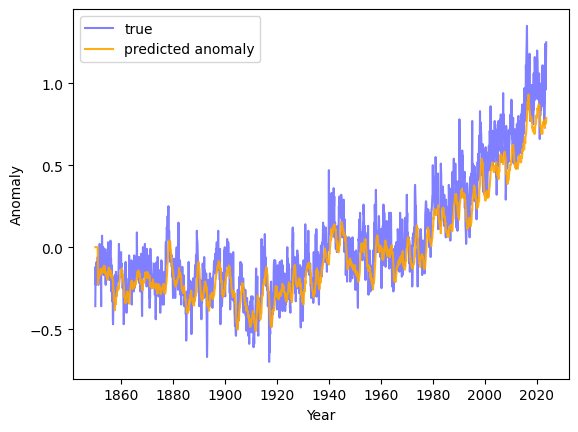

In [58]:
data["yhat"] = np.array(yhat)
sns.lineplot(data, x="Year", y="Anomaly", color="blue", alpha=0.5, label="true")
sns.lineplot(data, x="Year", y="yhat", color="orange", alpha=0.9, label="predicted anomaly")

In [37]:
# predicting 24 months into the future
xx = Xtrain[-1]
yy = []
timestamp = []
lasttime = data.Year[len(data)-1]

for i in range(24):
    pred = NN(params, xx)[0]
    pred = float(pred)
    lasttime = lasttime +  pd.DateOffset(months=1)
    timestamp.append(lasttime)
    yy.append(pred)

    xx = xx.tolist()[1:] + [pred]
    xx = np.array(xx)
    

<Axes: xlabel='Year', ylabel='Anomaly'>

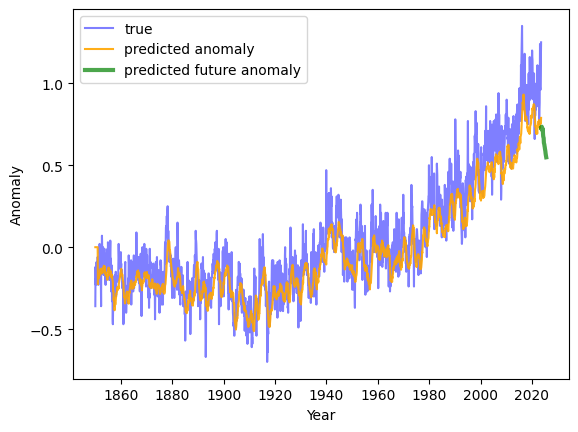

In [61]:
sns.lineplot(data, x="Year", y="Anomaly", color="blue", alpha=0.5, label="true")
sns.lineplot(data, x="Year", y="yhat", color="orange", alpha=0.9, label="predicted anomaly")
sns.lineplot(x=timestamp, y=yy, color="green", alpha=0.7, label="predicted future anomaly", linewidth=3)